# Clean up extracted conversations

In [61]:
input_dir = '../output/dialogues/pkna-*.json'
output_merged = '../output/dataset/dialogues-merged.json'
output_review = '../input/review/input.json'
output_high_review = '../input/review/hiq-review.json'
max_attribution_confidence = 5
min_line_confidence = 0.5
high_confidence = 0.85

recompute_merge = False

In [62]:
import glob

input_files = glob.glob(input_dir)
input_files.sort()

input_files[:10], len(input_files)

(['../output/dialogues/pkna-0-2-conv-005-0.json',
  '../output/dialogues/pkna-0-2-conv-005-1.json',
  '../output/dialogues/pkna-0-2-conv-005-2.json',
  '../output/dialogues/pkna-0-2-conv-005-3.json',
  '../output/dialogues/pkna-0-2-conv-011-0.json',
  '../output/dialogues/pkna-0-2-conv-011-1.json',
  '../output/dialogues/pkna-0-2-conv-011-2.json',
  '../output/dialogues/pkna-0-2-conv-011-3.json',
  '../output/dialogues/pkna-0-2-conv-011-4.json',
  '../output/dialogues/pkna-0-2-conv-011-5.json'],
 1046)

Sort better, by pkna num, conv num and page

In [63]:
# Better sort the files by pkna, conv, and page
import re

def input_sort_key(filename: str) -> tuple[float, int, int]:
    m = re.search(r'pkna-(.+)-conv-(.+)-(\d)+\.json', filename)
    if not m:
        raise ValueError(f"Filename {filename} does not match expected pattern.")
    pkna = float(m.group(1).replace('-', '.'))
    conv = int(m.group(2))
    page = int(m.group(3))
    return (pkna, conv, page)

input_files.sort(key=input_sort_key)
input_files[:10]

['../output/dialogues/pkna-0-conv-029-0.json',
 '../output/dialogues/pkna-0-conv-029-1.json',
 '../output/dialogues/pkna-0-conv-029-2.json',
 '../output/dialogues/pkna-0-conv-029-3.json',
 '../output/dialogues/pkna-0-conv-029-4.json',
 '../output/dialogues/pkna-0-conv-029-5.json',
 '../output/dialogues/pkna-0-conv-029-6.json',
 '../output/dialogues/pkna-0-conv-029-7.json',
 '../output/dialogues/pkna-0-conv-040-0.json',
 '../output/dialogues/pkna-0-conv-040-1.json']

In [64]:
import json
from dataclasses import dataclass


@dataclass
class Bubble:
    character: str
    text: str
    confidence: int

    def to_dict(self) -> dict:
        return {
            'character': self.character,
            'text': self.text,
            'confidence': self.confidence
        }


@dataclass
class Take:
    dialogue: list[Bubble]


@dataclass
class Page:
    input_page: str
    model: str
    prompt_version: str
    source: str
    takes: list[Take]

    @property
    def page_num(self) -> int:
        _, conv, offset = input_sort_key(self.source)
        return conv + offset

    @property
    def conv_num(self) -> int:
        _, conv, _ = input_sort_key(self.source)
        return conv

    @property
    def pkna(self) -> str:
        m = re.search(r'pkna-(.+)-conv-(.+)-(\d)+\.json', self.source)
        if not m:
            raise ValueError(
                f"Filename {self.source} does not match expected pattern")
        return f"PKNA #{m.group(1).replace('.', '/')}"

    def to_dict(self) -> dict:
        return {
            'input_page': self.input_page,
            'model': self.model,
            'prompt_version': self.prompt_version,
            'source': self.source,
            'pkna': self.pkna,
            'page_num': self.page_num,
            'conv_num': self.conv_num,
            'takes': [
                {
                    'dialogue': [b.to_dict() for b in t.dialogue]
                }
                for t in self.takes
            ]
        }


def read_json_file(filename: str) -> dict:
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)


def dict_to_page(filename: str, d: dict) -> Page:
    return Page(
        input_page=d['page'],
        model=d['model'],
        prompt_version=d['prompt_version'],
        source=filename,
        takes=[
            Take(dialogue=[
                Bubble(
                    character=b['character'],
                    text=b['text'],
                    confidence=b['probability'] / max_attribution_confidence
                )
                for b in t['dialogue']
            ])
            for t in d['takes']
        ]
    )


input_contents = [
    dict_to_page(filename, read_json_file(filename))
    for filename in input_files
]

input_contents[1].to_dict()

{'input_page': '../input/pkna/pkna-0/pkna-0-030.jpg',
 'model': 'gemini-2.5-flash-preview-04-17',
 'prompt_version': '2035c1e1',
 'source': '../output/dialogues/pkna-0-conv-029-1.json',
 'pkna': 'PKNA #0',
 'page_num': 30,
 'conv_num': 29,
 'takes': [{'dialogue': [{'character': 'Paperinik',
     'text': 'Immagino che ti aspetti spiegazioni! Mettiti comodo!',
     'confidence': 1.0},
    {'character': 'Uno', 'text': 'Molto gentile!', 'confidence': 1.0},
    {'character': 'Paperinik',
     'text': 'Dunque sei un computer?',
     'confidence': 1.0},
    {'character': 'Uno',
     'text': "Un'intelligenza artificiale, prego!",
     'confidence': 1.0},
    {'character': 'Uno',
     'text': "Per essere precisi, sono la piu' potente, versatile e sbalorditiva elligenza artificiale mai esistita su questo pianeta!",
     'confidence': 1.0},
    {'character': 'Uno',
     'text': 'Everett Ducklair mi ha programmato per avere qualcuno al suo livello intellettuale con cui parlare!',
     'confidence'

In [65]:
# Normalize character names
import re
import copy
from collections import Counter

char_clusters = {
    'paperinik': ['.*paperinik.*', 'pk', '.*donald duck.*'],
}
char_clusters = {
    k: [re.compile(f"^{v}$") for v in vs]
    for k, vs in char_clusters.items()
}

def normalize_characters(page: Page) -> Page:
    page = copy.deepcopy(page)
    for take in page.takes:
        for bubble in take.dialogue:
            c = bubble.character.strip().lower()
            for k, vs in char_clusters.items():
                if any(re.match(pattern, c) for pattern in vs):
                    c = k
                    break
            bubble.character = c
    return page

norm_characters = [
    normalize_characters(page)
    for page in input_contents
]

character_counts = Counter(
    bubble.character
    for page in norm_characters
    for take in page.takes
    for bubble in take.dialogue
)

character_counts.most_common(10)

[('paperinik', 15065),
 ('uno', 8263),
 ('everett ducklair', 3565),
 ('lyla lay', 229),
 ('woman with red hair', 95),
 ('green creature', 89),
 ('green alien', 81),
 ('angus fangus', 80),
 ('lyla', 66),
 ('purple creature', 63)]

Filter out pages that do not contain Uno at all

In [66]:
def contains_character(page: Page, character: str) -> bool:
    for take in page.takes:
        for bubble in take.dialogue:
            if bubble.character == character:
                return True
    return False

norm_uno_pages = [
    page
    for page in norm_characters
    if contains_character(page, 'uno')
]

# double-check how many pages we filtered out.
filtered_out = [
    page
    for page in norm_characters
    if not contains_character(page, 'uno')
]
len(filtered_out), filtered_out[0].takes[0].dialogue

(198,
 [Bubble(character='purple duck', text='Noi assorbiamo e utilizziamo le energie emotive e cerebrali delle forme di vita intelligente! Per questo abbiamo prelevato...', confidence=0.6),
  Bubble(character='purple duck', text="...a titolo sperimentale il vostro collega van beck! Speravamo che i protagonisti di 'patemi' catalizzassero le emozioni degli spettatori!", confidence=0.6),
  Bubble(character='paperinik', text='Senti, senti...', confidence=1.0),
  Bubble(character='tall purple character', text='Invece siete risultati scarsini. Ma non importa!', confidence=0.6),
  Bubble(character='purple duck', text='Prosciugandovi in massa, al party del caro sam, otterremo ugualmente una buona provvista energetica!', confidence=0.6),
  Bubble(character='character in pink cape', text="E' allucinante! Fa' qualcosa, sam!", confidence=0.6),
  Bubble(character='white fluffy character', text='Inutile, il vostro amico è già stato parzialmente assorbito!', confidence=0.6),
  Bubble(character='smal

Compute the best dialogue

In [67]:
from difflib import SequenceMatcher
from dataclasses import dataclass
import numpy as np
from tqdm import tqdm


@dataclass
class DialogueLine:
    character: str
    text: str
    match_confidence: float
    # List of alternatives to this line
    alternatives: list[Bubble]

    @property
    def confidence(self) -> float:
        ans_conf = float(np.mean([b.confidence for b in self.alternatives]))
        return .6 * self.match_confidence + .4 * ans_conf

    @property
    def uno_confidence(self) -> float:
        uno_bubbles = sum(1 for b in self.alternatives if b.character == 'uno')
        return uno_bubbles / len(self.alternatives) if self.alternatives else 0.0

    def to_dict(self) -> dict:
        return {
            'character': self.character,
            'text': self.text,
            'confidence': self.confidence,
            'match_confidence': self.match_confidence,
            'uno_confidence': self.uno_confidence,
            'alternatives': [
                {
                    'character': b.character,
                    'text': b.text,
                    'confidence': b.confidence
                }
                for b in self.alternatives
            ]
        }

@dataclass
class DialoguePage:
    input_page: str
    pkna: str
    page_num: int
    conv_num: int
    dialogue: list[DialogueLine]

    def to_dict(self) -> dict:
        return {
            'input_page': self.input_page,
            'pkna': self.pkna,
            'page_num': self.page_num,
            'conv_num': self.conv_num,
            'dialogue': [d.to_dict() for d in self.dialogue]
        }

    @staticmethod
    def from_dict(d: dict) -> "DialoguePage":
        return DialoguePage(
            input_page=d['input_page'],
            pkna=d['pkna'],
            page_num=d['page_num'],
            conv_num=d['conv_num'],
            dialogue=[
                DialogueLine(
                    character=dl['character'],
                    text=dl['text'],
                    match_confidence=dl['match_confidence'],
                    alternatives=[
                        Bubble(
                            character=b['character'],
                            text=b['text'],
                            confidence=b['confidence']
                        )
                        for b in dl['alternatives']
                    ]
                )
                for dl in d['dialogue']
            ]
        )


def text_similarity(a: str, b: str) -> float:
    """Calculate similarity between two strings"""
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


def find_best_matches(takes: list[Take], threshold: float = 0.8) -> list[DialogueLine]:
    all_dialogues: list[DialogueLine] = []

    # First, align similar bubbles across takes
    for take in takes:
        for bubble in take.dialogue:
            matched = False
            # Try to match with existing dialogues
            for dialogue in all_dialogues:
                if text_similarity(bubble.text, dialogue.alternatives[0].text) > threshold:
                    dialogue.alternatives.append(bubble)
                    matched = True
                    break

            if not matched:
                # Create new dialogue group
                all_dialogues.append(DialogueLine(
                    character=bubble.character,
                    text=bubble.text,
                    match_confidence=1.0,
                    alternatives=[bubble]
                ))

    # Calculate most likely character and text for each dialogue
    result = []
    for dialogue in all_dialogues:
        # Count character occurrences
        char_counts: dict[str, int] = {}
        for bubble in dialogue.alternatives:
            char_counts[bubble.character] = char_counts.get(
                bubble.character, 0) + 1

        # Find most common character
        most_common_char = max(char_counts.items(), key=lambda x: x[1])

        # Find most representative text (highest average similarity)
        text_scores: dict[str, float] = {}
        for bubble1 in dialogue.alternatives:
            score = 0
            for bubble2 in dialogue.alternatives:
                score += text_similarity(bubble1.text, bubble2.text)
            text_scores[bubble1.text] = score / len(dialogue.alternatives)

        best_text = max(text_scores.items(), key=lambda x: x[1])[0]

        result.append(DialogueLine(
            character=most_common_char[0],
            text=best_text,
            match_confidence=most_common_char[1] / len(takes),
            alternatives=dialogue.alternatives
        ))

    # Sort by position in original sequences
    def get_avg_position(dialogue: DialogueLine) -> float:
        positions = []
        for take in takes:
            for i, bubble in enumerate(take.dialogue):
                if any(text_similarity(bubble.text, alt.text) > threshold
                       for alt in dialogue.alternatives):
                    positions.append(i)
        return float(np.mean(positions)) if positions else float('inf')

    result.sort(key=get_avg_position)

    return result

In [68]:
import os
import json

def compute_merge() -> list[DialoguePage]:
    merged_runs = [
        DialoguePage(
            input_page=page.input_page,
            pkna=page.pkna,
            page_num=page.page_num,
            conv_num=page.conv_num,
            dialogue=find_best_matches(page.takes)
        )
        for page in tqdm(norm_uno_pages)
    ]
    # Save the merged runs to a file
    os.makedirs(os.path.dirname(output_merged), exist_ok=True)
    with open(output_merged, 'w', encoding='utf-8') as f:
        json.dump([page.to_dict() for page in merged_runs], f, ensure_ascii=False, indent=4)
    return merged_runs

def load_merge() -> list[DialoguePage]:
    with open(output_merged, 'r', encoding='utf-8') as f:
        merged_runs = json.load(f)
    return [DialoguePage.from_dict(page) for page in merged_runs]

# Load or compute the merged runs
merged_runs = compute_merge() if recompute_merge else load_merge()

In [69]:
for line in merged_runs[0].dialogue:
    print(f"{line.character} ({line.confidence:.2f}) [uno? {line.uno_confidence:.2f}]: {line.text}")

paperinik (0.98) [uno? 0.00]: Hai paura di affrontarmi? Fatti vedere!
paperinik (1.00) [uno? 0.00]: Veramente, mi stai già guardando!
paperinik (0.59) [uno? 0.40]: Io sono questo edificio!
paperinik (0.59) [uno? 0.40]: Ma se proprio hai bisogno di un volto a cui rivolgerti... ecco!
paperinik (1.00) [uno? 0.00]: Glom! Penso di averne viste abbastanza, per una sola notte!
paperinik (1.00) [uno? 0.00]: Facciamoci coraggio!
paperinik (1.00) [uno? 0.00]: Non so cosa tu sia, ma hai di fronte Paperinik!
uno (1.00) [uno? 1.00]: Piacere! Io sono Uno!
paperinik (0.98) [uno? 0.00]: Uno, eh? Dove hai lasciato gli altri?
paperinik (1.00) [uno? 0.00]: Groan! Che battutaccia! È terribile!


From now on, store versions of the dialogue pages in elements of `pages_version`.

Additionally prepare a set of pages that will require review, in `pages_to_review`.

In [70]:
pages_version = [merged_runs]
pages_to_review = set[str]()

## Filter out pages without Uno

In [71]:
pages = [
    page
    for page in pages_version[-1]
    if (
        any(line.character == 'uno' for line in page.dialogue) or
        any(line.uno_confidence > 0.2 for line in page.dialogue)
    )
]

print(f"{len(pages)}/{len(pages_version[-1])} pages with 'uno' with some confidence")

771/848 pages with 'uno' with some confidence


In [72]:
pages_version.append(pages)
[len(x) for x in pages_version]

[848, 771]

## Identify low confidence pages

In [73]:
imperfect_pages = [
    page
    for page in pages_version[-1]
    if any(line.confidence < min_line_confidence for line in page.dialogue)
]
print(f"{len(imperfect_pages)}/{len(pages_version[-1])} pages have some low confidence lines.")

363/771 pages have some low confidence lines.


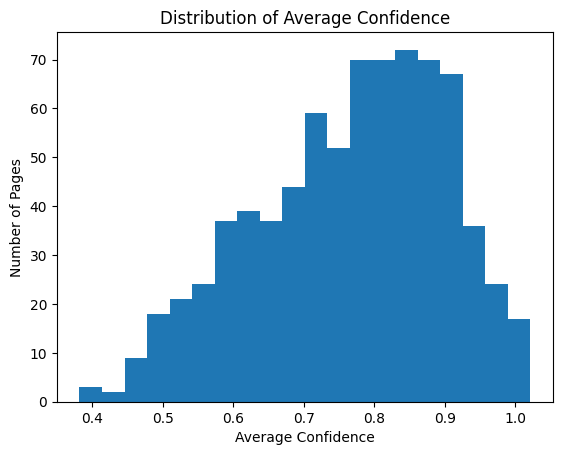

In [74]:
# Distribution of average confidence
import matplotlib.pyplot as plt
import numpy as np

avg_confidences = [
    np.mean([line.confidence for line in page.dialogue])
    for page in pages_version[-1]
]
plt.hist(avg_confidences, bins=20)
plt.xlabel("Average Confidence")
plt.ylabel("Number of Pages")
plt.title("Distribution of Average Confidence")
plt.show()

In [75]:
low_conf_pages = [
    page
    for page in merged_runs
    if np.mean([line.confidence for line in page.dialogue]) <= min_line_confidence
]

# Sample of low confidence page
len(low_conf_pages), low_conf_pages[0].to_dict()

(41,
 {'input_page': '../input/pkna/pkna-0-3/PK.Vol.0-3 002.jpg',
  'pkna': 'PKNA #0-3',
  'page_num': 2,
  'conv_num': 2,
  'dialogue': [{'character': 'green/orange alien creature',
    'text': '...e di pericoloso!',
    'confidence': 0.44000000000000006,
    'match_confidence': 0.2,
    'uno_confidence': 0.0,
    'alternatives': [{'character': 'green/orange alien creature',
      'text': '...e di pericoloso!',
      'confidence': 0.8},
     {'character': 'coolflame (in sphere)',
      'text': '...e di pericoloso!',
      'confidence': 0.8},
     {'character': 'small green creature',
      'text': '... E di pericoloso!',
      'confidence': 0.8},
     {'character': 'alien creature',
      'text': '...e di pericoloso!',
      'confidence': 0.8},
     {'character': 'coolflame creature',
      'text': '...e di pericoloso!',
      'confidence': 0.8}]},
   {'character': 'uno',
    'text': 'Che cosa fate qui, voi Coolflames?',
    'confidence': 0.5760000000000001,
    'match_confidence': 0.

In [76]:
pages_to_review.update((
    page.input_page
    for page in low_conf_pages
))

len(pages_to_review)

41

## Remove spurious lines

Remove dialogue lines that are likely just spurious (i.e. with less than 2 alternatives).

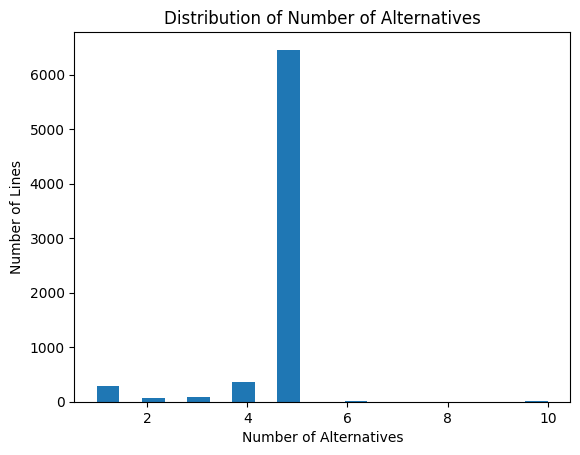

In [77]:
# Distribution of number of alternatives
import matplotlib.pyplot as plt

num_alternatives = [
    len(line.alternatives)
    for page in merged_runs
    for line in page.dialogue
]
plt.hist([n for n in num_alternatives if n <= 10], bins=20)
plt.xlabel("Number of Alternatives")
plt.ylabel("Number of Lines")
plt.title("Distribution of Number of Alternatives")
plt.show()

In [78]:
import numpy as np
min(num_alternatives), max(num_alternatives), float(np.mean(num_alternatives))

(1, 55, 4.76541518224171)

In [79]:
def is_spurious_line(line: DialogueLine) -> bool:
    return len(line.alternatives) < 2

def has_spurious_lines(page: DialoguePage) -> bool:
    """Check if the page has any lines with low confidence or high number of alternatives."""
    return any(
        is_spurious_line(line)
        for line in page.dialogue
    )

def need_spurious_lines_review(page: DialoguePage) -> bool:
    """Check if the page has any lines with low confidence or high number of alternatives."""
    return any(
        len(line.alternatives) > 6
        for line in page.dialogue
    )

In [80]:
spurious_lines = [
    line
    for page in pages_version[-1]
    for line in page.dialogue
    if is_spurious_line(line)
]
len(spurious_lines), [l.text for l in spurious_lines[:10]]

(267,
 ['... --- ...',
  '---',
  'li ho distanziati.',
  'posso puntare verso casa!',
  'E così... Evroniani, eh?',
  "... Si'...",
  'Ah! Ah! This city is really comic!',
  'Go back! You owe me sixty-seven dollars and twelve cents!',
  'Stop him! Eh? But where did he go?',
  'Do you think Lyla is right, Uno?'])

In [81]:
from copy import deepcopy

# Drop any lines that have less than 3 alternatives
pages_new = []

for page in pages_version[-1]:
    if need_spurious_lines_review(page):
        pages_to_review.add(page.input_page)
    if not has_spurious_lines(page):
        pages_new.append(page)
        continue

    # Filter out bad lines.
    new_dialogue = deepcopy(page)
    new_dialogue.dialogue = [
        line
        for line in page.dialogue
        if is_spurious_line(line)
    ]
    pages_new.append(new_dialogue)

pages_version.append(pages_new)
[len(x) for x in pages_version]

[848, 771, 771]

In [82]:
len(pages_to_review)

56

## Join conversations

Group pages together in conversations.

In [84]:
@dataclass
class Conversation:
    pages: list[DialoguePage]
    score: float = 0.0

    @property
    def characters(self) -> list[str]:
        """Get the set of characters in the conversation."""
        return sorted(list({
            line.character
            for page in self.pages
            for line in page.dialogue
        }))

    @property
    def characters_score(self) -> int:
        wanted = set(['uno', 'paperinik'])
        got = set(self.characters)
        positive = got.intersection(wanted)
        negative = got.difference(wanted)
        return len(positive)*2 - len(negative)

    @property
    def num_pages_score(self) -> int:
        return len(self.pages)

    @property
    def confidence_score(self) -> float:
        """Calculate the average confidence of the conversation."""
        confidences = [
            np.mean([line.confidence for line in page.dialogue])
            for page in self.pages
        ]
        return float(np.mean(confidences)) if confidences else 0.0

    def to_dict(self) -> dict:
        return {
            'pkna': self.pages[0].pkna,
            'page_range': [page.page_num for page in self.pages],
            'characters': self.characters,
            'score': self.score,
            'pages': [page.to_dict() for page in self.pages]
        }


conversations = []

curr_conv: list[DialoguePage] = []

for page in pages_version[-1]:
    if curr_conv and (curr_conv[-1].page_num + 1) != page.page_num:
        conversations.append(Conversation(pages=curr_conv))
        curr_conv = []
    curr_conv.append(page)
if curr_conv:
    conversations.append(Conversation(pages=curr_conv))

len(conversations)

403

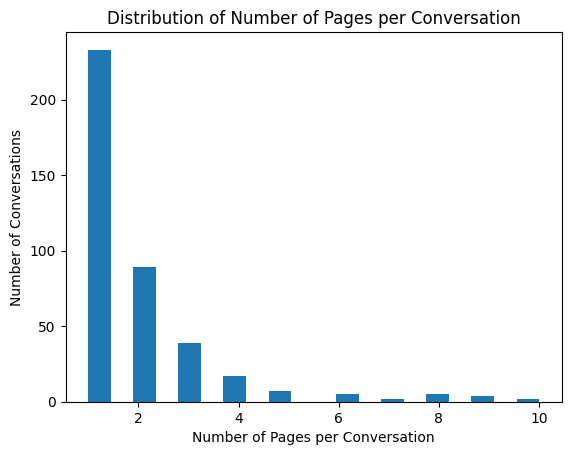

In [85]:
# plot the distribution of number of pages per conversation
import matplotlib.pyplot as plt
page_counts = [len(conv.pages) for conv in conversations]
plt.hist(page_counts, bins=20)
plt.xlabel("Number of Pages per Conversation")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Number of Pages per Conversation")
plt.show()

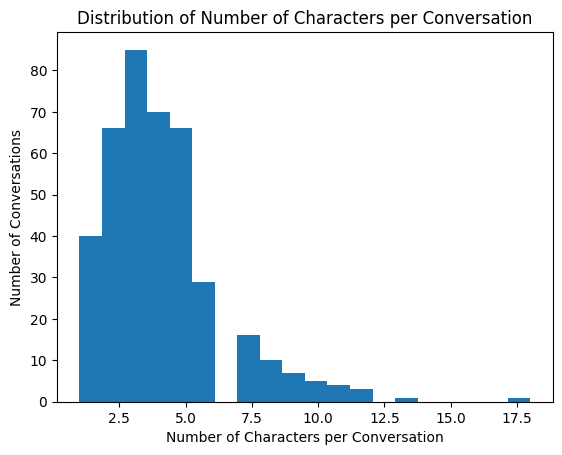

In [86]:
# Plot the distribution of number of characters per conversation
char_counts = [len(conv.characters) for conv in conversations]
plt.hist(char_counts, bins=20)
plt.xlabel("Number of Characters per Conversation")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Number of Characters per Conversation")
plt.show()

In [87]:
# What are the most common characters in the same conversation?
from collections import Counter

char_counter = Counter(
    ",".join(conv.characters)
    for conv in conversations
)
char_counter.most_common(20)

[('paperinik,uno', 53),
 ('everett ducklair,paperinik,uno', 38),
 ('uno', 12),
 ('paperinik', 11),
 ('everett ducklair,paperinik', 5),
 ('evroniano,paperinik,uno', 2),
 ('everett ducklair,paperinik,uno,woman with red hair', 2),
 ('everett ducklair,paperinik,robot (blue),uno', 1),
 ('character in teal suit', 1),
 ('hidden figure', 1),
 ('everett ducklair,paperinik,purple alien,purple alien (evroniano),uno', 1),
 ('evronian commander,evronian soldier,news anchor,news announcer (duck),paperinik,uno',
  1),
 ('angus fangus,news anchor on tv,paperinik,uno', 1),
 ('everett ducklair,paperinik,scrooge mcduck,uno', 1),
 ('old man at desk,old man standing,paperinik,uno', 1),
 ('bird in red cape,paperinik,uno', 1),
 ('woman with hat', 1),
 ('everett ducklair,narrator,paperinik,police officer,uno', 1),
 ('coolflame,green/orange alien creature,uno,white/purple alien creature', 1),
 ('benny gym,paperinik,uno,woman with short dark hair', 1)]

In [97]:
# Compute the score through combination of softmax of the three scores
import numpy as np


def softmax(nums: list[int | float]) -> list[float]:
    exp_scores = np.exp(nums - np.max(nums))
    softmax_scores = exp_scores / np.sum(exp_scores)
    return softmax_scores.tolist()


def compute_scores(conversations: list[Conversation]) -> None:
    char_scores = softmax([c.characters_score for c in conversations])
    num_pages_scores = softmax([c.num_pages_score for c in conversations])
    confidence_scores = softmax([c.confidence_score for c in conversations])

    for i, conv in enumerate(conversations):
        conv.score = (
            0.4 * confidence_scores[i] +
            0.3 * char_scores[i] +
            0.3 * num_pages_scores[i]
        )

    # Sort conversations by score
    conversations.sort(key=lambda c: c.score, reverse=True)


compute_scores(conversations)
conversations[0].to_dict()

{'pkna': 'PKNA #2',
 'page_range': [6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 'characters': ['angus fangus',
  'everett ducklair',
  'paperinik',
  'uno',
  'woman with dark curly hair'],
 'score': 0.06754884119226894,
 'pages': [{'input_page': '../input/pkna/pkna-2/pkna2-06.jpg',
   'pkna': 'PKNA #2',
   'page_num': 6,
   'conv_num': 6,
   'dialogue': [{'character': 'everett ducklair',
     'text': 'Sei pronto, Paperinik?',
     'confidence': 0.6960000000000001,
     'match_confidence': 0.6,
     'uno_confidence': 0.2,
     'alternatives': [{'character': 'everett ducklair',
       'text': 'Sei pronto, Paperinik?',
       'confidence': 0.8},
      {'character': 'everett ducklair',
       'text': 'Sei pronto, Paperinik?',
       'confidence': 0.6},
      {'character': 'uno',
       'text': 'Sei pronto, paperinik?',
       'confidence': 0.8},
      {'character': 'paperinik',
       'text': 'Sei pronto, Paperinik?',
       'confidence': 1.0},
      {'character': 'everett ducklair',
       'te

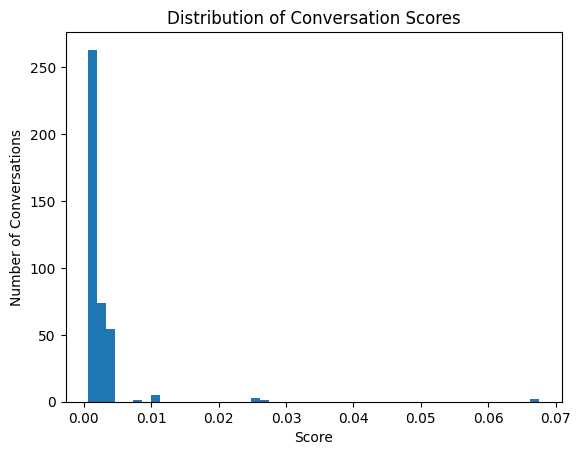

In [89]:
# Plot the distribution of scores
import matplotlib.pyplot as plt

scores = [conv.score for conv in conversations]
plt.hist(scores, bins=50)
plt.xlabel("Score")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Conversation Scores")
plt.show()

## Prepare review dataset (TODO)

In [98]:
import json
import os


def drop_alt(p: dict) -> dict:
    """Only keep the main text and character."""
    return {
        'dialogue': [
            {
                'character': line['character'],
                'text': line['text'],
            }
            for line in p['dialogue']
        ]
    }


def write_review_file(pages: list[DialoguePage], filename: str) -> None:
    """Write the review file"""
    data = [
        {
            'image': page.input_page,
            'ocr': drop_alt(page.to_dict()),
            'full': page.to_dict(),
        }
        for page in pages
    ]
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

In [99]:
write_review_file(low_conf_pages, output_review)

## Review high quality pages

In [100]:
high_quality_pages = [
    page
    for page in merged_runs
    if np.average([line.confidence for line in page.dialogue]) > high_confidence
    and sum(
        line.character == 'uno' for line in page.dialogue
    ) > 2
]
high_quality_pages.sort(key=lambda p: np.average([line.confidence for line in p.dialogue]), reverse=True) # type: ignore
len(high_quality_pages)

140

In [101]:
write_review_file(high_quality_pages, output_high_review)

## Dataset (TODO)

In [94]:
# Split by pkna and conversation
import pandas as pd

df = pd.DataFrame.from_records([
    {
        'pkna': page.pkna,
        'page_num': page.page_num,
        'conv_num': page.conv_num,
        'input_page': page.input_page,
        'dialogue': [
            {
                'character': line.character,
                'text': line.text,
                'confidence': line.confidence,
                'uno_confidence': line.uno_confidence
            }
            for line in page.dialogue
        ]
    }
    for page in merged_runs
])

df.head()

,pkna,page_num,conv_num,input_page,dialogue
0,PKNA #0,29,29,../input/pkna/pkna-0/pkna-0-029.jpg,"[{'character': 'paperinik', 'text': 'Hai paura..."
1,PKNA #0,30,29,../input/pkna/pkna-0/pkna-0-030.jpg,"[{'character': 'paperinik', 'text': 'Immagino ..."
2,PKNA #0,31,29,../input/pkna/pkna-0/pkna-0-031.jpg,"[{'character': 'uno', 'text': 'Raccontartela p..."
3,PKNA #0,32,29,../input/pkna/pkna-0/pkna-0-032.jpg,"[{'character': 'paperinik', 'text': '...E ha l..."
4,PKNA #0,33,29,../input/pkna/pkna-0/pkna-0-033.jpg,"[{'character': 'paperinik', 'text': 'Scommetto..."
